Este é um registro detalhado do desenvolvimento do projeto de classificação de gripe utilizando o algoritmo ID3 (Iterative Dichotomiser 3). O processo seguiu uma abordagem experimental de Ciência de Dados, passando por fases de diagnóstico, correção de erros de lógica e otimização de hiperparâmetros.

---


## **1. Definição do Problema e Carga de Dados**
O objetivo era prever se uma pessoa ficaria gripada com base em hábitos de vida (sono, estresse, higiene, etc.). Os dados foram extraídos de uma planilha do Google Sheets com 186 registros.

**Erro Inicial: Identificação do Alvo (Target)**

No início, houve uma falha na interpretação da estrutura da tabela. O algoritmo foi configurado para olhar a última coluna da planilha como o "Alvo", quando, na verdade, essa coluna continha notas subjetivas (1 a 5). O alvo real era a Coluna B, que continha a resposta binária ("Sim" ou "Não") para a pergunta: "Você ficou gripado no ano passado?".


---


## **2. Tratamento e Limpeza de Dados (Data Wrangling)**
Nesta fase, enfrentamos os erros mais críticos de execução.


*   O Erro do dropna(): Inicialmente, aplicamos uma limpeza agressiva que excluía qualquer linha com valores ausentes. Isso resultou em um conjunto de dados vazio, fazendo com que a árvore gerasse apenas um nó nulo (None).

**Solução**: Mudamos para a Imputação pela Moda, onde buracos nos dados foram preenchidos com o valor mais frequente da coluna, preservando o tamanho da amostra.

*   Conflito de Tipos (String vs Int): Colunas como "Estresse" e "Sono" continham números interpretados como texto, causando falhas no cálculo matemático da Entropia.

**Solução**: Implementamos a conversão forçada para numérico (pd.to_numeric) e tratamos erros de digitação.


---


## **3. Implementação do Algoritmo ID3**
O algoritmo foi construído do zero, focando em:


*   Entropia de Shannon: Para medir a desordem dos dados.
*   Ganho de Informação: Para selecionar, em cada nível, qual pergunta (atributo) melhor separava quem ficou gripado de quem não ficou.

**Lógica de Discretização**

Um erro comum no ID3 "puro" é tentar criar um ramo para cada número diferente (ex: um ramo para 7 horas de sono, outro para 7.1 horas). Isso gera árvores infinitas e inúteis.
Correção: Aplicamos a Discretização em Bins. O Estresse foi agrupado em "Baixo/Alto" e o Sono em categorias, simplificando a tomada de decisão da árvore.

## **4. Otimização e Testes de Profundidade (Tuning)**
Com o motor funcionando, iniciamos os testes de Profundidade Máxima (max_depth) para encontrar o equilíbrio entre decorar os dados (Overfitting) e aprender padrões reais.

Profundidade

**NV-03:** 59,46% Observação: Modelo simples, mas promissor.

**NV-05:** 56,76% Observação: Overfitting inicial: a árvore ficou complexa e perdeu precisão no teste.

**NV-07:** 62,16% Observação: Ponto Ideal (Sweet Spot): Melhor equilíbrio encontrado.

**NV-08 a 10:** 62,16% Observação: Platô: A acurácia estagnou. Aumentar a complexidade não trouxe ganho.

---

## **5. Seleção de Atributos (Feature Selection)**
Tentamos uma "Limpeza de Primavera", removendo colunas com baixa correlação aparente (Alimentação e Exercício) para tentar quebrar o teto de 62,16%.
* Resultado: A acurácia caiu drasticamente para 54,05%.
* Lição Aprendida: Mesmo que um atributo pareça fraco individualmente, ele pode ser o "desempate" crucial em níveis profundos da árvore. O modelo final teve melhor performance mantendo todos os atributos originais.

---

## **6. Solução Final Encontrada**
A solução definitiva para o registro do projeto consiste em:
Algoritmo: ID3 customizado com suporte a dados categóricos.

1. **Pré-processamento:** Imputação por moda e discretização de variáveis numéricas.
Configuração de Sucesso: Profundidade 7, utilizando todas as colunas disponíveis.
2. **Performance:** 62,16% de acurácia na base de teste (37 registros não vistos pelo modelo).
3. **Visualização:** Representação gráfica em blocos coloridos (Azul para decisões, Verde/Vermelho para resultados), facilitando a rastreabilidade da decisão.









In [65]:
import pandas as pd
import numpy as np


# ACESSO E CONFIGURAÇÃO
# Carga dos dados
url = "https://docs.google.com/spreadsheets/d/1g1aQ61vijh6uHJuc8sijeBEMsoIQ2a5yLwUK04Wptlg/export?format=csv&gid=282951434"
df_raw = pd.read_csv(url)

# Nomes curtos para facilitar a vida
# Coluna 0: Timestamp, Coluna 1: Gripe (O ALVO), Coluna 2: Vacina...
df_raw.columns = ["TS", "Gripe", "Vacina", "Ambientes", "Viajou", "Alergia",
                  "Sono", "Exercicio", "Alimentacao", "Maos", "Estresse"]

# Limpeza inicial: Remover espaços em branco das respostas de texto
df_raw['Gripe'] = df_raw['Gripe'].astype(str).str.strip()

print(f"Total de registros: {len(df_raw)}")
print("\n--- Verificação do Alvo (Coluna B) ---")
print(df_raw['Gripe'].value_counts())

# Amostra para confirmar se os dados são Sim/Não
display(df_raw[['Gripe', 'Vacina', 'Estresse']].head())

Total de registros: 186

--- Verificação do Alvo (Coluna B) ---
Gripe
Sim    109
Não     77
Name: count, dtype: int64


,Gripe,Vacina,Estresse
0,Sim,Sim,5.0
1,Sim,Sim,3.0
2,Sim,Não,3.0
3,Sim,Não,2.0
4,Sim,Sim,4.0


In [64]:
#Parte 2: Limpeza e Divisão
df_clean = df_raw.copy()

# Remover apenas o Timestamp
df_clean = df_clean.drop(columns=["TS"])

# Tratar valores vazios (NaN) nas colunas preditoras
for col in df_clean.columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Discretização do Estresse (Notas 1-5 -> Baixo/Alto)
df_clean['Estresse'] = pd.to_numeric(df_clean['Estresse'], errors='coerce').fillna(3)
df_clean['Estresse'] = pd.cut(df_clean['Estresse'], bins=[0, 3, 5], labels=['Baixo', 'Alto'])

# Divisão 80/20
train_df = df_clean.sample(frac=0.8, random_state=42)
test_df = df_clean.drop(train_df.index)

features = [c for c in train_df.columns if c != "Gripe"]

print(f"Treino: {len(train_df)} | Teste: {len(test_df)}")
print(f"Atributos que serão usados: {features}")

Treino: 149 | Teste: 37
Atributos que serão usados: ['Vacina', 'Ambientes', 'Viajou', 'Alergia', 'Sono', 'Exercicio', 'Alimentacao', 'Maos', 'Estresse']


In [66]:
#Parte 3: Definição do Motor ID3
# Célula de Definição de Lógica
def entropy(s):
    _, counts = np.unique(s, return_counts=True)
    probs = counts / len(s)
    return -np.sum(probs * np.log2(probs))

def info_gain(df, attr, target):
    total_ent = entropy(df[target])
    vals, counts = np.unique(df[attr], return_counts=True)
    w_ent = np.sum([(counts[i]/len(df)) * entropy(df[df[attr] == vals[i]][target]) for i in range(len(vals))])
    return total_ent - w_ent

def id3(data, features, target, max_depth=3, curr_depth=0, parent_class=None):
    # Casos base para evitar erros de recursão
    if len(data) == 0: return parent_class
    if len(np.unique(data[target])) == 1: return data[target].iloc[0]

    current_mode = data[target].mode()[0]
    if not features or curr_depth >= max_depth: return current_mode

    # Seleção do melhor atributo pelo Ganho de Informação
    gains = [info_gain(data, f, target) for f in features]
    best_f = features[np.argmax(gains)]

    tree = {best_f: {}}
    for val in np.unique(data[best_f]):
        sub_data = data[data[best_f] == val]
        subtree = id3(sub_data, [f for f in features if f != best_f], target, max_depth, curr_depth + 1, current_mode)
        tree[best_f][val] = subtree
    return tree

print("Motor ID3 pronto para uso.")

Motor ID3 pronto para uso.


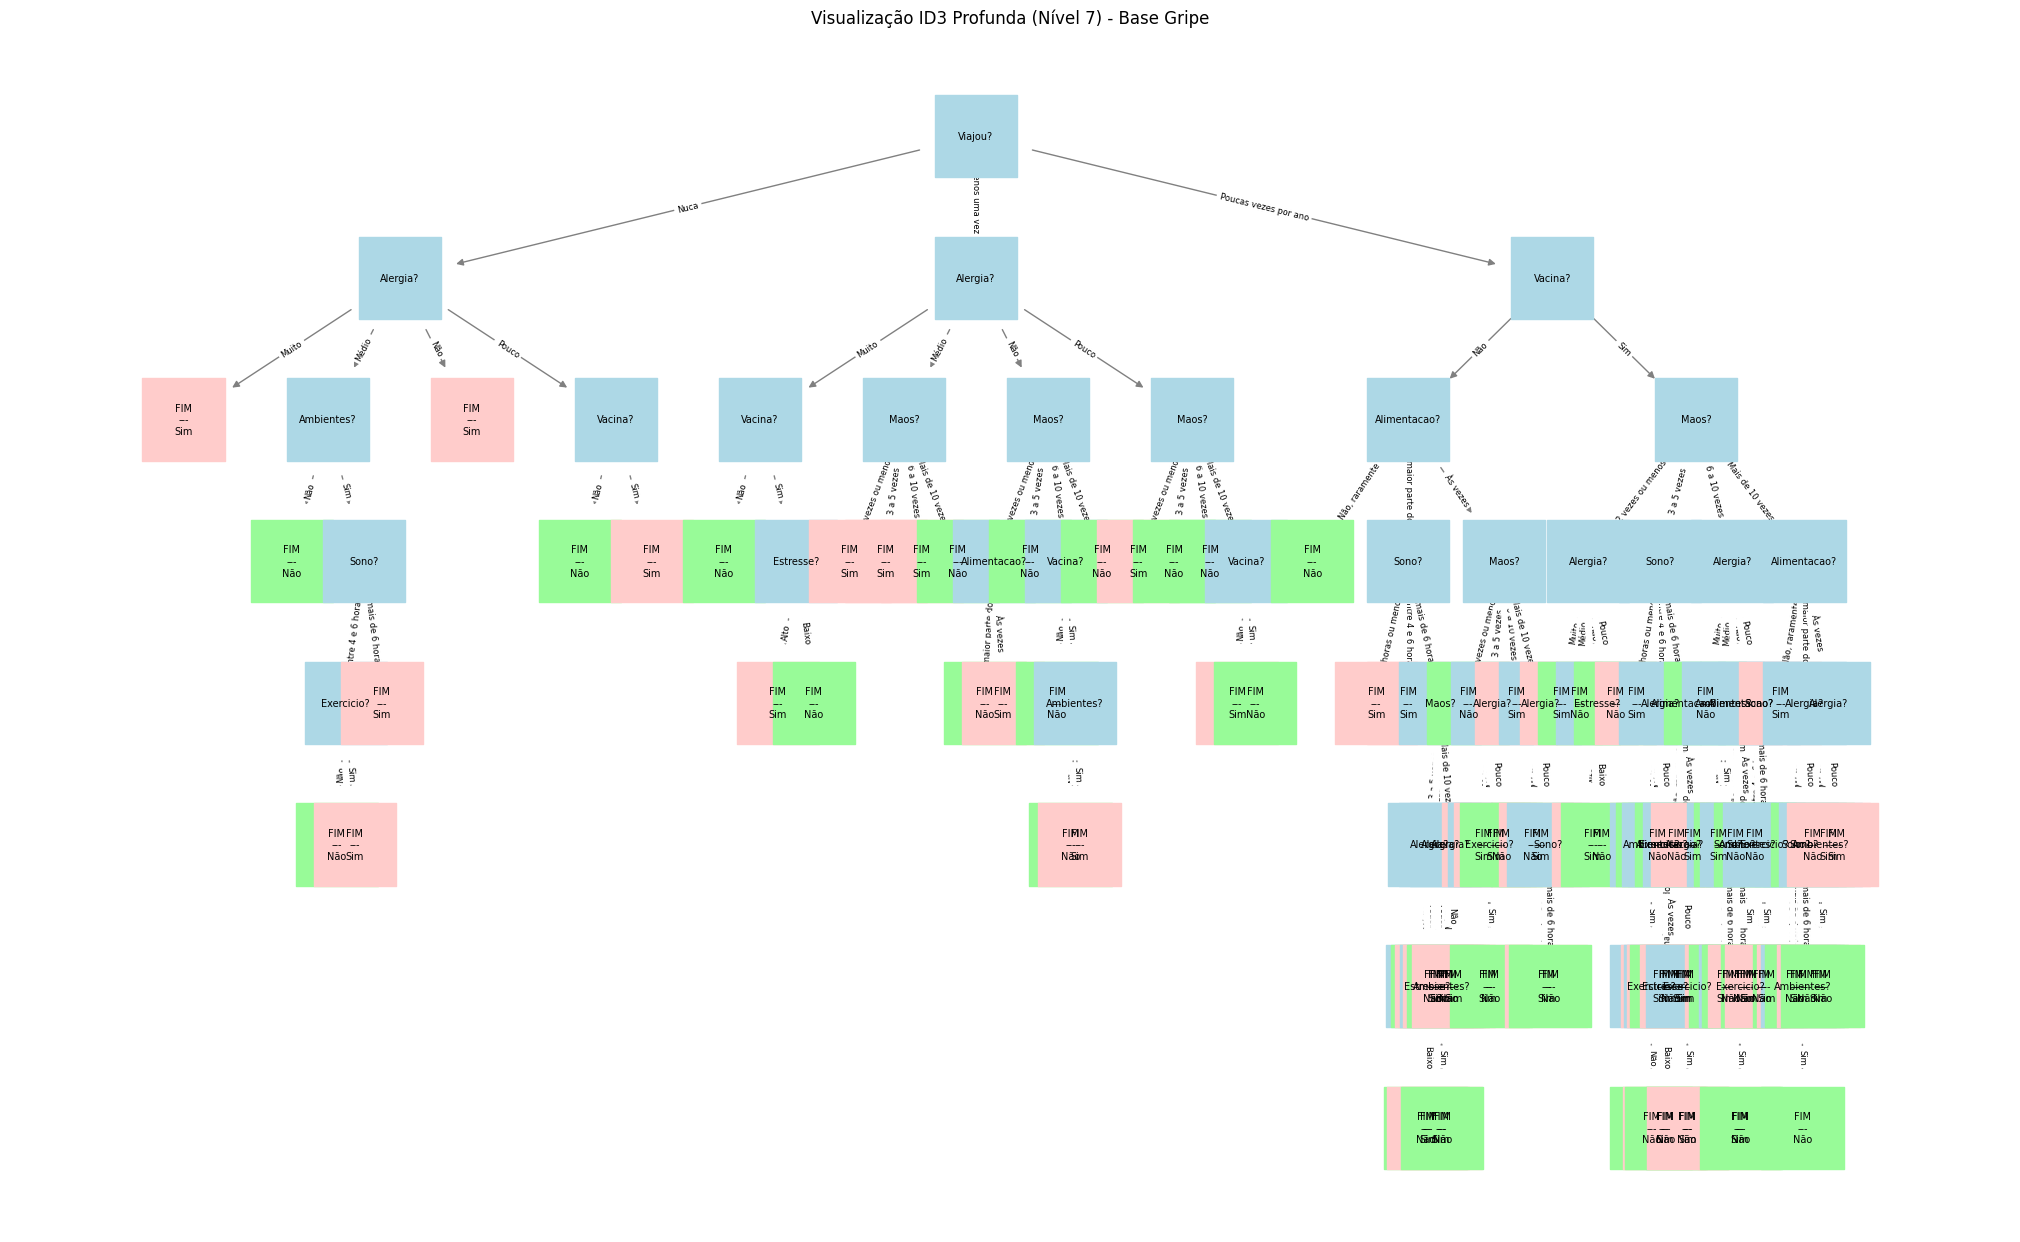


ACURÁCIA DE TESTE COM PROFUNDIDADE 7: 62.16%


In [85]:
#Parte 4: Geração da Árvore e Acurácia
# 1. Construir a árvore com profundidade maior (Ajuste o valor aqui)
PROFUNDIDADE_DESEJADA = 7 #PROFUNDIDADE IDEAL ENCONTRADA 7 (MAIOR MANTEM A ACURACIDADE, MENOR DIMINUI A ACURACIDADE)
arvore_profunda = id3(train_df, features, "Gripe", max_depth=PROFUNDIDADE_DESEJADA)

# 2. Visualização Gráfica Expandida
def draw_tree_visual_expanded(tree):
    G = nx.DiGraph()
    pos, labels, colors = {}, {}, []

    def build_graph(sub, p_id=None, e_lab=None, lv=0, x=0, w=10.0): # Aumentei o w para dar mais espaço
        n_id = str(np.random.rand())
        G.add_node(n_id)
        pos[n_id] = (x, -lv)
        if p_id: G.add_edge(p_id, n_id, label=e_lab)

        if not isinstance(sub, dict):
            labels[n_id] = f"FIM\n---\n{sub}"
            colors.append('#98fb98' if sub == 'Não' else '#ffcccb')
            return

        attr = next(iter(sub))
        labels[n_id] = f"{attr}?"
        colors.append('#add8e6')

        filhos = sub[attr]
        num_filhos = len(filhos)
        for i, (v, b) in enumerate(filhos.items()):
            # Cálculo de x para espalhar os ramos
            new_x = x - w/2 + (i + 0.5) * (w/num_filhos)
            build_graph(b, n_id, v, lv + 1, new_x, w/num_filhos)

    build_graph(tree)

    # Aumentei o figsize para suportar a profundidade maior
    plt.figure(figsize=(20, 12))

    nx.draw(G, pos, labels=labels, with_labels=True,
            node_size=3500, # Diminuí um pouco o tamanho do nó para caber mais
            node_shape='s',
            node_color=colors,
            font_size=7, # Fonte menor para não sobrepor
            edge_color='gray',
            width=1)

    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)

    plt.title(f"Visualização ID3 Profunda (Nível {PROFUNDIDADE_DESEJADA}) - Base Gripe")
    plt.show()

draw_tree_visual_expanded(arvore_profunda)

# 3. Novo Cálculo de Acurácia
acc_profunda = (test_df.apply(lambda r: predict(arvore_profunda, r), axis=1) == test_df["Gripe"]).sum() / len(test_df) * 100
print(f"\nACURÁCIA DE TESTE COM PROFUNDIDADE {PROFUNDIDADE_DESEJADA}: {acc_profunda:.2f}%")